In [ ]:
library(Seurat)
library(dplyr)
library(ggalluvial)
library(tidyr)
library(scRepertoire)
library(viridis)
library(scales)
library(RColorBrewer)

# Supp Fig 7

In [2]:
t_cells <- readRDS('../Fig2b_c_d_VST2/seurat_objects/vst2_t_cells.rds')

In [3]:
t_cells

An object of class Seurat 
18168 features across 647032 samples within 2 assays 
Active assay: RNA (18129 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: escape.ssGSEA
 2 dimensional reductions calculated: pca, umap

## Clonal Capture Over Time

## Clean up TCR

In [4]:
library(stringr)

Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [5]:
meta <- t_cells@meta.data %>%
  mutate(
    TRAV = str_extract(CTgene, "TRAV[^*]*"),
    TRAJ = str_extract(CTgene, "TRAJ[^*]*"),
    TRAC = str_extract(CTgene, "TRAC[^*]*"),
    TRBV = str_extract(CTgene, "TRBV[^*]*"),
    TRBJ = str_extract(CTgene, "TRBJ[^*]*"),
    TRBC = str_extract(CTgene, "TRBC[^*]*")
  )
head(meta)

,orig.ident,nCount_RNA,nFeature_RNA,barcodes,AIFI_PBMC.Flex_L1,AIFI_PBMC.Flex_L2,AIFI_PBMC.Flex_L3,batch_id,cell_name,cell_uuid,⋯,Culture_Peptide,RNA_snn_res.0.8,seurat_clusters,pep_enriched,TRAV,TRAJ,TRAC,TRBV,TRBJ,TRBC
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1de16aa05c2011f0a76a2e8167d1be4d,SeuratProject,29867,6645,1de16aa05c2011f0a76a2e8167d1be4d,T cell,Proliferating T cell,Proliferating T cell,EXP-01589-PC,vegetal_sphingine_krill,1de16aa05c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,19,19,Non-Activated,TRAV38-1,TRAJ21,TRAC,TRBV28,TRBJ2-7,TRBC2
1de16b545c2011f0a76a2e8167d1be4d,SeuratProject,949,758,1de16b545c2011f0a76a2e8167d1be4d,T cell,Treg,Memory CD4 Treg,EXP-01589-PC,carbonous_improved_xerus,1de16b545c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,21,21,Non-Activated,NA,NA,NA,NA,NA,NA
1de16c625c2011f0a76a2e8167d1be4d,SeuratProject,1650,1217,1de16c625c2011f0a76a2e8167d1be4d,T cell,Memory CD4 T cell,CM CD4 T cell,EXP-01589-PC,unrelative_heathenish_koalabear,1de16c625c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,21,21,Non-Activated,TRAV4,TRAJ3,TRAC,TRBV3-1,TRBJ2-5,TRBC2
1de16d5c5c2011f0a76a2e8167d1be4d,SeuratProject,1831,1279,1de16d5c5c2011f0a76a2e8167d1be4d,T cell,Memory CD8 T cell,ISG+ memory CD4 T cell,EXP-01589-PC,cold_greenish_chrysalis,1de16d5c5c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,0,0,Non-Activated,NA,NA,NA,TRBV24-1,TRBJ2-2,TRBC2
1de16dde5c2011f0a76a2e8167d1be4d,SeuratProject,1651,1146,1de16dde5c2011f0a76a2e8167d1be4d,T cell,Naive CD4 T cell,ISG+ naive CD4 T cell,EXP-01589-PC,landpoor_loving_wallaroo,1de16dde5c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,0,0,Non-Activated,TRAV26-1,TRAJ49,TRAC,TRBV3-1,TRBJ2-3,TRBC2
1de16e565c2011f0a76a2e8167d1be4d,SeuratProject,3839,2306,1de16e565c2011f0a76a2e8167d1be4d,T cell,gdT,Adaptive NK cell,EXP-01589-PC,censorable_detestable_fox,1de16e565c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,7,7,Non-Activated,NA,NA,NA,NA,NA,NA


In [6]:
t_cells$CTgene_archive <- t_cells$CTgene
t_cells$CTgene <- paste0(meta$TRAV,'.',meta$TRAJ,'.',meta$TRAC,'_',meta$TRBV,'.',meta$TRBJ,'.',meta$TRBC)

In [7]:
t_cells$CTaa_TRA <- stringr::str_split_i(string = t_cells$CTaa, pattern = '_', i = 1)
t_cells$CTaa_TRB <- stringr::str_split_i(string = t_cells$CTaa, pattern = '_', i = 2)

In [8]:
t_cells$CDR3a <- stringr::str_split_i(string = t_cells$CTaa_TRA, pattern = ';', i = 1)
t_cells$CTaa_TRA_2 <- stringr::str_split_i(string = t_cells$CTaa_TRA, pattern = ';', i = 2)
t_cells$CDR3b <- stringr::str_split_i(string = t_cells$CTaa_TRB, pattern = ';', i = 1)
t_cells$CTaa_TRB_2 <- stringr::str_split_i(string = t_cells$CTaa_TRB, pattern = ';', i = 2)

In [9]:
t_cells$CTaa_archive <- t_cells$CTaa
t_cells$CTaa <- paste(t_cells$CDR3a,t_cells$CDR3b,sep='_')

In [10]:
meta <- t_cells@meta.data

In [11]:
table(is.na(meta$CDR3a))
table(is.na(meta$CDR3b))


 FALSE   TRUE 
557839  89193 


 FALSE   TRUE 
557839  89193 

In [12]:
meta$CDR3a[is.na(meta$CDR3a)] <- 'NA'
meta$CDR3b[is.na(meta$CDR3b)] <- 'NA'

In [13]:
tra_idx <- meta$CDR3a != 'NA'
trb_idx <- meta$CDR3b != 'NA'

In [14]:
meta$clone_type <- 'No Clone'
meta$clone_type[tra_idx] <- 'TRA'
meta$clone_type[trb_idx] <- 'TRB'
meta$clone_type[tra_idx & trb_idx] <- 'TRA;TRB'

In [15]:
table(meta$clone_type)


No Clone      TRA  TRA;TRB      TRB 
   89193    69145   414433    74261 

## Plot

In [31]:
summary_clone_type <- meta %>%
    group_by(Day, clone_type) %>%
    summarise(count = n())

`summarise()` has grouped output by 'Day'. You can override using the `.groups`
argument.


In [16]:
perc_clone_capture <- meta %>%
    group_by(Donor, Day, clone_type) %>%
    summarise(count = n()) %>%
    group_by(Donor, Day) %>%
    mutate(percentage = count / sum(count) * 100) %>%
    group_by(Donor, Day) %>%
    filter(clone_type != 'No Clone') %>%
    summarise(clone_perc = sum(percentage))
head(perc_clone_capture)

`summarise()` has grouped output by 'Donor', 'Day'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'Donor'. You can override using the
`.groups` argument.


Donor,Day,clone_perc
<chr>,<fct>,<dbl>
BW2164,Day_0,66.90275
BW2164,Day_4,79.30919
BW2164,Day_7,86.59983
BW2164,Day_10,86.74448
BW3446,Day_0,70.04333
BW3446,Day_4,82.58003


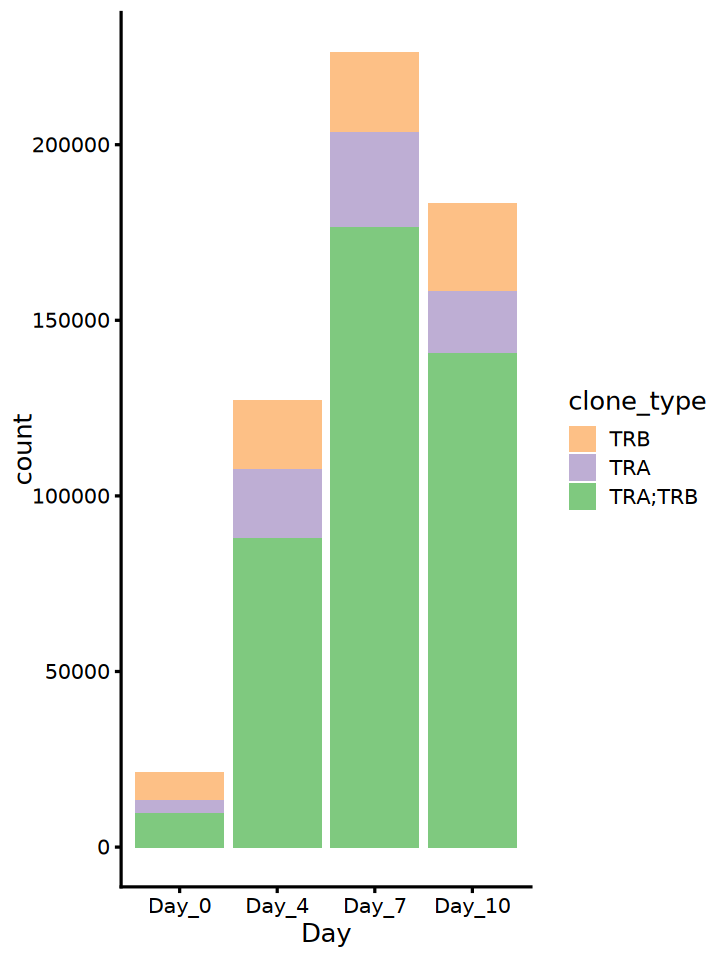

In [35]:
options(repr.plot.width = 6, repr.plot.height = 8)
summary_clone_type %>% 
    filter(clone_type != 'No Clone') %>%
    mutate(clone_type = factor(clone_type, levels = c('TRB','TRA','TRA;TRB'))) %>%
    ggplot(aes(x=Day, y=count, fill=clone_type)) + 
        geom_bar(stat='identity') + 
        # geom_text(aes(label = round(percentage,2)), 
        #           position = position_stack(vjust = 0.5), 
        #           size = 4, color = "black") +
        theme_classic(base_size = 15) + 
        scale_fill_manual(values = c('#fdc086','#beaed4','#7fc97f'))

In [36]:
# Open the PDF graphics device
pdf("plots/Supp_Fig7_Total_Clones.pdf", width = 6, height = 8) # You can specify width and height in inches

# Create your plot
summary_clone_type %>% 
    filter(clone_type != 'No Clone') %>%
    mutate(clone_type = factor(clone_type, levels = c('TRB','TRA','TRA;TRB'))) %>%
    ggplot(aes(x=Day, y=count, fill=clone_type)) + 
        geom_bar(stat='identity') + 
        # geom_text(aes(label = round(percentage,2)), 
        #           position = position_stack(vjust = 0.5), 
        #           size = 4, color = "black") +
        theme_classic(base_size = 15) + 
        scale_fill_manual(values = c('#fdc086','#beaed4','#7fc97f'))

# Close the graphics device to save the plot
dev.off()

pdf 
  2

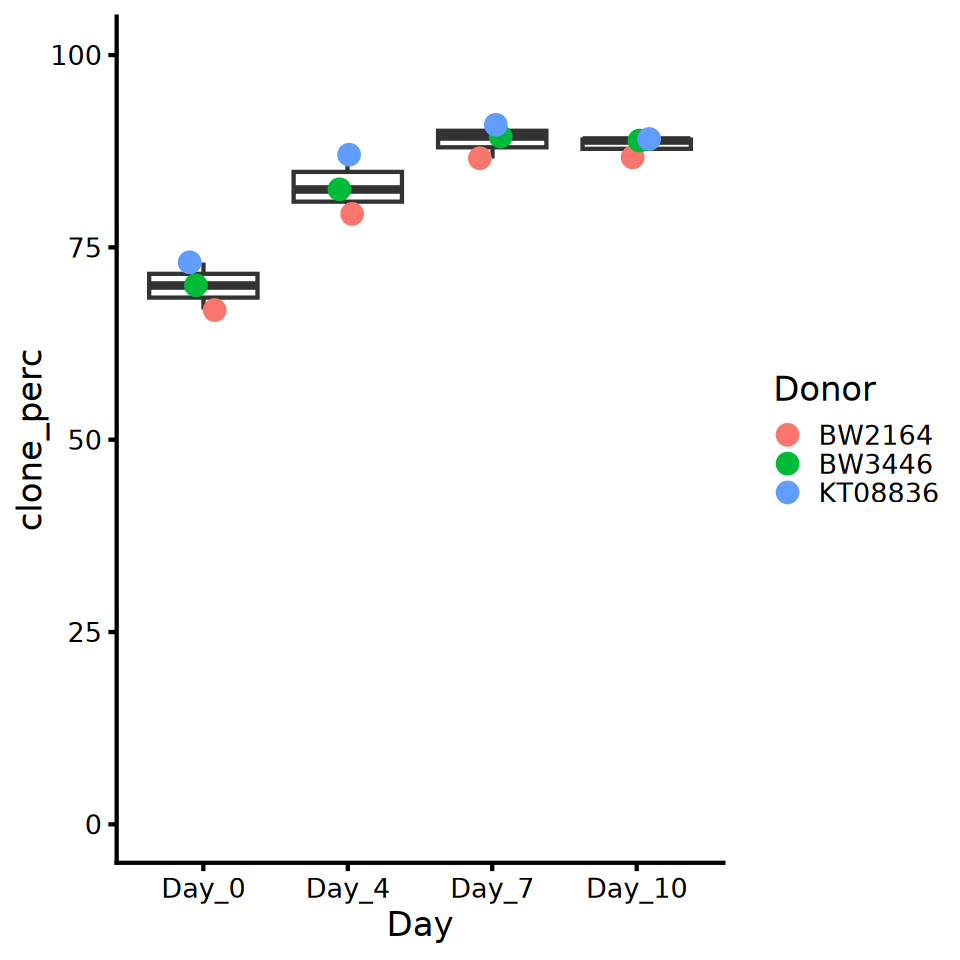

In [37]:
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(perc_clone_capture, aes(x=Day, y=clone_perc)) + geom_boxplot() + 
    geom_jitter(aes(color=Donor), size=5, width=0.1) +
    theme_classic(base_size=20) + ylim(0,100)

In [38]:
# Open the PDF graphics device
pdf("plots/Supp_Fig7_Proportion_Clones.pdf", width = 8, height = 8) # You can specify width and height in inches

# Create your plot
ggplot(perc_clone_capture, aes(x=Day, y=clone_perc)) + geom_boxplot() + 
    geom_jitter(aes(color=Donor), size=5, width=0.1) +
    theme_classic(base_size=20) + ylim(0,100)

# Close the graphics device to save the plot
dev.off()

pdf 
  2